In [1]:
from helpers import load_config
import os
import h5py
config_path = os.path.abspath("pyloco_config.py")
load_config(config_path=config_path)
from pyloco import pyloco, remove_bad_bpms, plot_data
import numpy as np
import at
from pyloco_config import FitInitConfig, fixed_parameters, loco_options


ring = at.load_lattice('betamodel.mat',  use='betamodel')
elements_ind = at.get_refpts(ring, "*")
cor_indices =  at.get_refpts(ring, 'S[HFDIJ]*')
used_bpm = at.get_refpts(ring, at.elements.Monitor)
quad_indices = at.get_refpts(ring, at.elements.Quadrupole)
QD3 =at.get_refpts(ring, 'QD3[AE]*')
QF4 =at.get_refpts(ring, 'QF4[ABDE]*')
QD5 =at.get_refpts(ring, 'QD5[BD]*')
combined = np.concatenate((QD3, QF4, QD5))
quad_indices = np.sort(combined)
CAVords =  at.get_refpts(ring, at.elements.RFCavity)
sext_indices = at.get_refpts(ring, at.elements.Sextupole)
skew_ord = at.get_refpts(ring, 'S[HFDIJ]*')

_, _, twiss = at.get_optics(ring, elements_ind)
# ============================================================================== #
#                Prepare quadrupoles,skews, correctors, bpms, cavity indices
# ============================================================================== #

def load_names(filename):
    with open(filename, 'r') as file:
        names = [line.strip() for line in file.readlines()]
    return names



#used_bpm = at.get_refpts(ring, at.elements.Monitor)

Corords = [cor_indices, cor_indices]
CAVords = at.get_refpts(ring, at.elements.RFCavity)

# --- Load Measurments ---
with h5py.File("./data/measured_orm_loco.h5", "r") as f:
    measured_orm = np.array(f["response_matrix"]) # in meter [BPMs X Cor]

with h5py.File("./data/measured_dispersion_loco.h5", "r") as f:  # in meter
    measured_eta_x_ = np.array(f["measured_eta_x"])
    measured_eta_y_ = np.array(f["measured_eta_y"])
    attrs_eta = dict(f.attrs)

with h5py.File("./data/measured_BPM_noise_loco.h5", "r") as f:  # in meter
    Noise_BPMx = np.array(f["Noise_BPMx"])
    Noise_BPMy = np.array(f["Noise_BPMy"])
    attrs_noise = dict(f.attrs)


# ============================================================================== #
#               Remove bad BPMs from measurment data
# ============================================================================== #

used_bpms_ords = used_bpm


#bad_bpm_ind = [1973, 5639, 5681, 5825, 6011, 6087, 6197, 6297, 6311, 7641]
#bad_bpm_positions = np.array([24, 104, 108, 111, 123, 138, 144, 153, 161,162, 243])
#Noise_BPMx_cleaned = np.delete(Noise_BPMx, bad_bpm_positions)
#Noise_BPMy_cleaned = np.delete(Noise_BPMy, bad_bpm_positions)
#sigma_w = np.concatenate((Noise_BPMx_cleaned, Noise_BPMy_cleaned))[:, np.newaxis]  # Note: weight matrix shape for pyloco
#used_bpms_ords = np.delete(used_bpm, bad_bpm_positions)

sigma_w = np.concatenate((Noise_BPMx, Noise_BPMy))[:, np.newaxis]
used_bpms_ords = used_bpm

#measured_eta_x = np.delete(measured_eta_x_, bad_bpm_positions)
#measured_eta_y = np.delete(measured_eta_y_, bad_bpm_positions)

measured_eta_x = measured_eta_x_
measured_eta_y = measured_eta_y_


#measured_orm , removed = remove_bad_bpms(measured_orm,
#                                     bad_bpm_positions,
#                                     total_bpms=len(used_bpm),
#                                     axis=0,
#                                     input_type="positions")

CMstep = [[100e-6] * len(Corords[0]),
         [100e-6] * len(Corords[1])]

/Users/elafmusa/py312/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)



==== Iteration 1/10 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/output/quad_jacobian_logs.txt'
Initial Chi²: 5.3048e+06


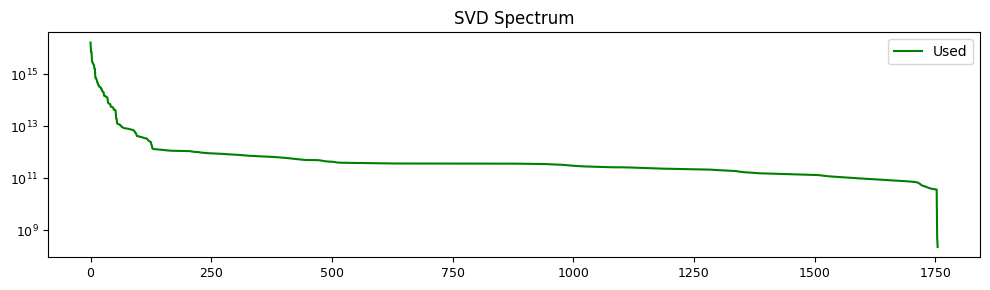

  LM inner 1: chi² 8.6186e+04 (previous 5.3048e+06), λ=0.001
Chi² after correction: 8.6186e+04

==== Iteration 2/10 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/output/quad_jacobian_logs.txt'
Initial Chi²: 8.6186e+04


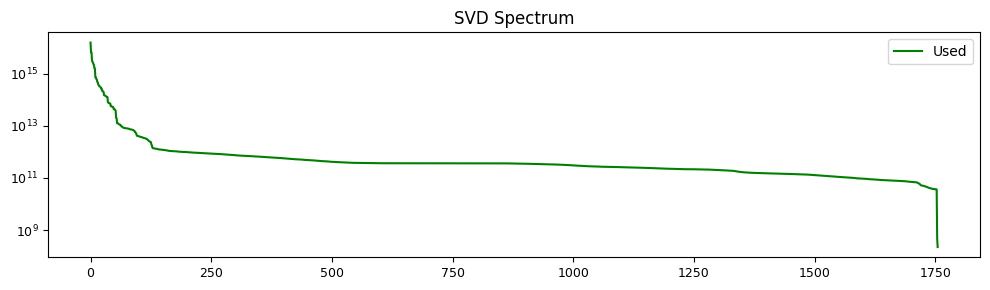

  LM inner 1: chi² 7.0388e+04 (previous 8.6186e+04), λ=0.001
Chi² after correction: 7.0388e+04

==== Iteration 3/10 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/output/quad_jacobian_logs.txt'
Initial Chi²: 7.0291e+04


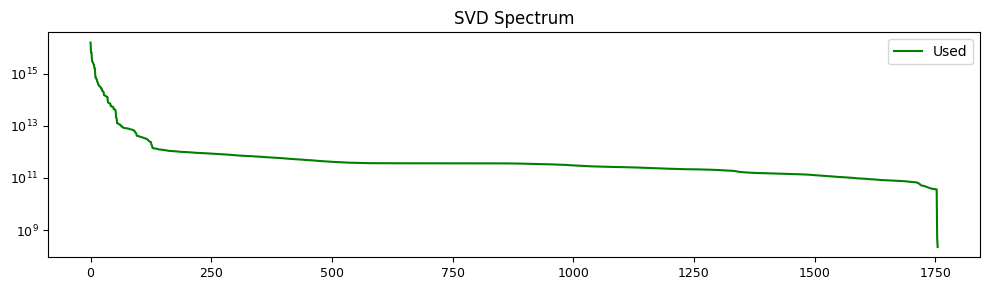

  LM inner 1: chi² 6.9862e+04 (previous 7.0291e+04), λ=0.001
Chi² after correction: 6.9862e+04

==== Iteration 4/10 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/output/quad_jacobian_logs.txt'
Initial Chi²: 6.9862e+04


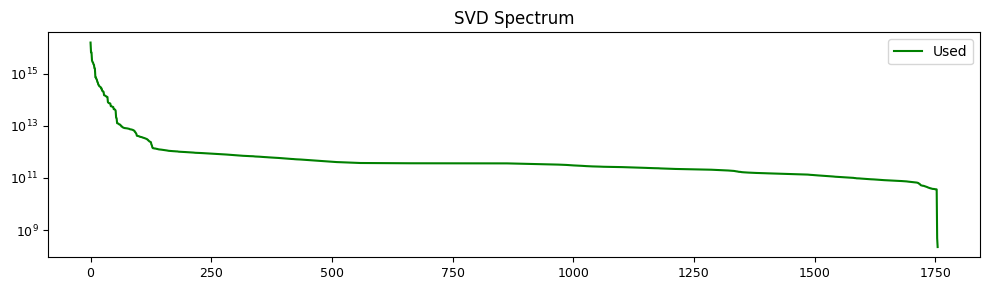

  LM inner 1: chi² 6.9707e+04 (previous 6.9862e+04), λ=0.001
Chi² after correction: 6.9707e+04

==== Iteration 5/10 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/output/quad_jacobian_logs.txt'
Initial Chi²: 6.9707e+04


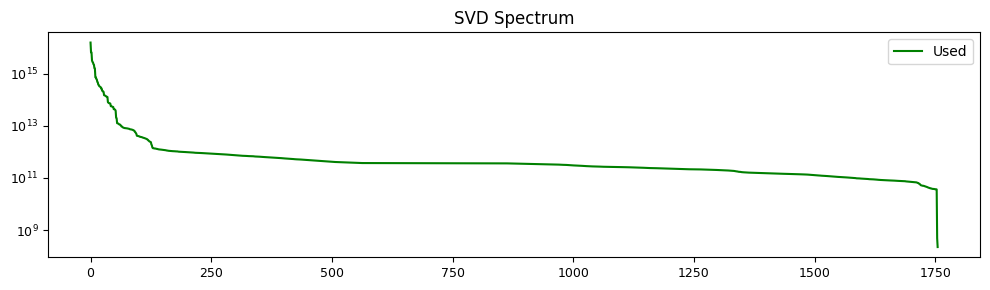

  LM inner 1: chi² 6.9618e+04 (previous 6.9707e+04), λ=0.001
Chi² after correction: 6.9618e+04

==== Iteration 6/10 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/output/quad_jacobian_logs.txt'
Initial Chi²: 6.9618e+04


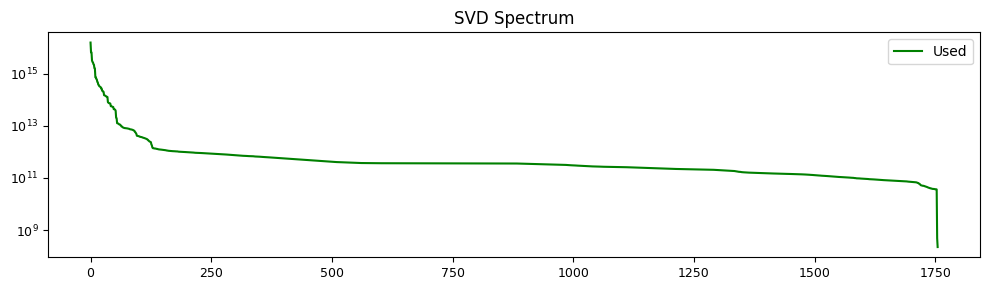

  LM inner 1: chi² 6.9549e+04 (previous 6.9618e+04), λ=0.001
Chi² after correction: 6.9549e+04

==== Iteration 7/10 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/output/quad_jacobian_logs.txt'
Initial Chi²: 6.9549e+04


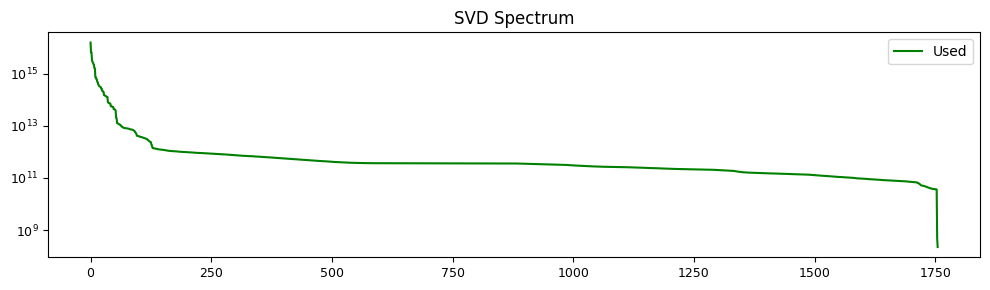

  LM inner 1: chi² 6.9487e+04 (previous 6.9549e+04), λ=0.001
Chi² after correction: 6.9487e+04

==== Iteration 8/10 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/output/quad_jacobian_logs.txt'
Initial Chi²: 6.9487e+04


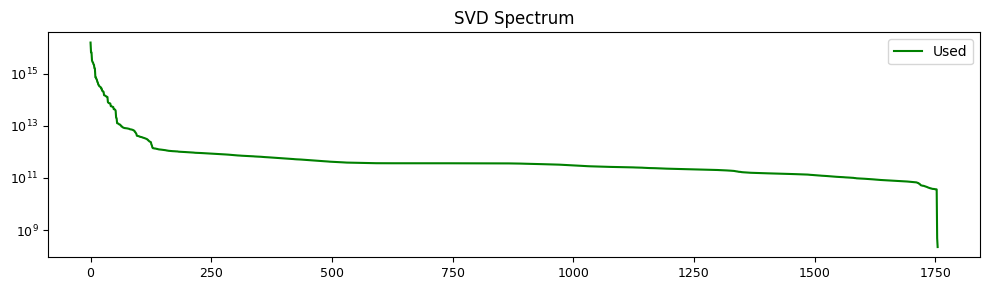

  LM inner 1: chi² 6.9429e+04 (previous 6.9487e+04), λ=0.001
Chi² after correction: 6.9429e+04

==== Iteration 9/10 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/output/quad_jacobian_logs.txt'
Initial Chi²: 6.9429e+04


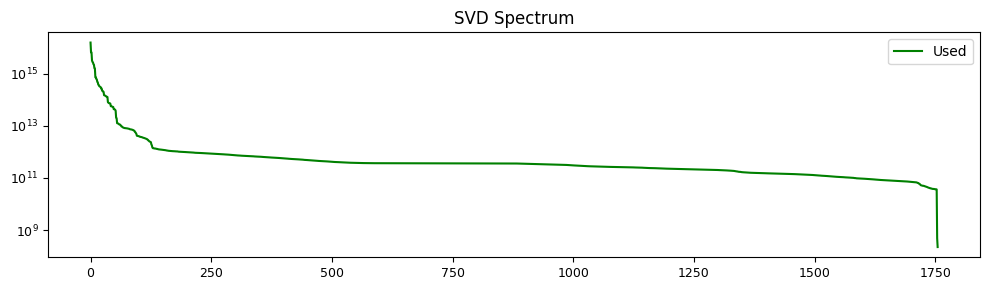

  LM inner 1: chi² 6.9374e+04 (previous 6.9429e+04), λ=0.001
Chi² after correction: 6.9374e+04

==== Iteration 10/10 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/output/quad_jacobian_logs.txt'
Initial Chi²: 6.9374e+04


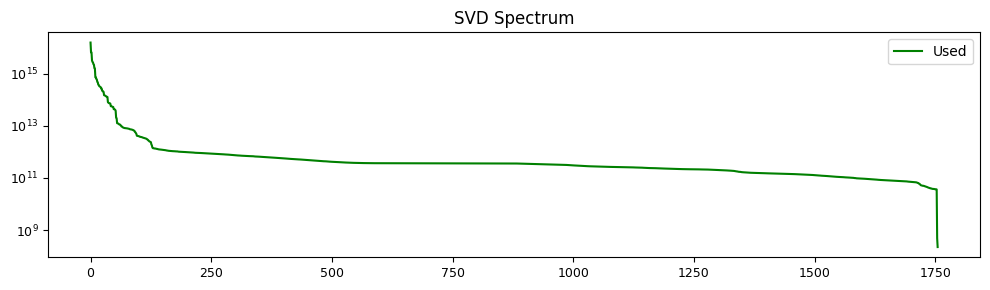

  LM inner 1: chi² 6.9320e+04 (previous 6.9374e+04), λ=0.001
Chi² after correction: 6.9320e+04
LOCO LM completed! :).


In [2]:
fit_cfg = FitInitConfig()
ring.disable_6d()
# --- define arguments ---

nHorCOR    = len(Corords[0])
nVerCOR    = len(Corords[1])
nHBPM = nVBPM = len(used_bpms_ords)
nIter      = 10
svd_threshold = 1e-10
'''
fit_list = [
        "quads",
        'skew_quads',
        'quads_tilt',
        "hbpm_gain",
        "vbpm_gain",
        "hcor_cal",
        "vcor_cal",
    "HCMEnergyShift",
    "VCMEnergyShift",
        'hbpm_coupling',
        'vbpm_coupling',
        'hcor_coupling',
        'vcor_coupling'
    ]
'''
fit_list = [
        "quads",
        "hbpm_gain",
        "vbpm_gain",
        "hcor_cal",
        "vcor_cal",
        "HCMEnergyShift"
    ]
remove_coupling_ = True
includeDispersion = False
fixedpathlength = False
fit_results, fit_dict, ring = pyloco(
    ring,

    # --- general control ---
    algorithm=loco_options.algorithm,
    nIter= nIter,

    # --- indices & number of elements ---
    used_bpms_ords=used_bpms_ords,
    used_cor_ords=Corords,
    quads_ords=quad_indices,
    skew_ords=skew_ord,
    CAVords=CAVords,
    nHBPM=nHBPM,
    nVBPM=nVBPM,
    nHorCOR=nHorCOR,
    nVerCOR=nVerCOR,
    quads_tilt_ind=quad_indices,
    inetial_fit_parameters=None,

    # --- measurement data ---
    orm_measured=measured_orm,
    weights=sigma_w,
    includeDispersion=includeDispersion,
    measured_eta_x=measured_eta_x,
    measured_eta_y=measured_eta_y,
    hor_dispersion_weight=loco_options.hor_dispersion_weight,
    ver_dispersion_weight=loco_options.ver_dispersion_weight,

    # --- correctors kicks & RF ---
    CMstep=CMstep,
    rfStep=fixed_parameters.rfstep,
    Frequency=fixed_parameters.Frequency,

    # --- features ---
    fit_list=fit_list,
    individuals=loco_options.individuals,
    remove_coupling_= remove_coupling_,

    # --- outliers & normalization ---
    outlier_rejection=loco_options.outlier_rejection,
    sigma_outlier=loco_options.sigma_outlier,
    apply_normalization=loco_options.apply_normalization,
    normalization_mode=loco_options.normalization_mode,

    # --- SVD selection ---
    svd_selection_method=loco_options.svd_selection_method,
    svd_threshold = svd_threshold,
    cut_=loco_options.cut_,
    show_svd_plot=loco_options.show_svd_plot,

    # --- LM options ---
    nLMIter=loco_options.nLMIter,
    Starting_Lambda=loco_options.Starting_Lambda,
    max_lm_lambda=loco_options.max_lm_lambda,
    scaled=loco_options.scaled,

    # --- more options ---
    plot_fit_parameters=loco_options.plot_fit_parameters,
    auto_correct_delta=loco_options.auto_correct_delta,
    fixedpathlength= fixedpathlength,
    fit_cfg=fit_cfg,
)

# --- save results ---
np.save("./output/loco_lm_fit_results_iterations.npy", fit_results)

Lattice tune after loco : [0.16672109 0.33842757]


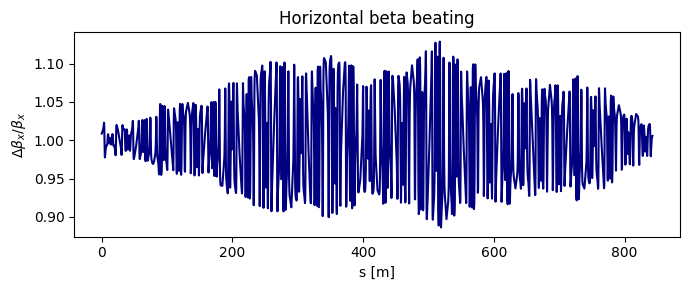

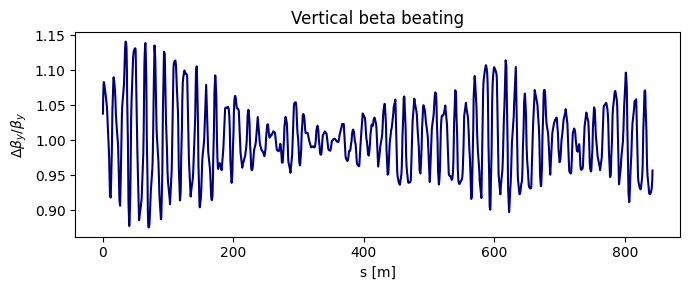

In [3]:
print('Lattice tune after loco :' , at.get_tune(ring))
_, _, twiss_err = at.get_optics(ring, elements_ind)
s_pos = twiss_err.s_pos
bx = (twiss_err.beta[:, 0]) / twiss.beta[:, 0]
by = (twiss_err.beta[:, 1]) / twiss.beta[:, 1]
plot_data(s_pos, bx, "s [m]", r"$\Delta\beta_x / \beta_x$ ", "Horizontal beta beating")
plot_data(s_pos, by, "s [m]", r"$\Delta\beta_y / \beta_y$ ", "Vertical beta beating")